# Publication-Quality Visualizations

**Plan 2 - Task 8**

Targeted visualizations addressing each research question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../datasets/student_exam_features.csv')

# Recompute target correlations
numeric_df = df.select_dtypes(include='number').drop(columns=['student_id'], errors='ignore')
corr = numeric_df.corr()
target_corr = corr['final_exam_score'].drop('final_exam_score').sort_values(key=abs, ascending=False)

## RQ1 - Feature Importance Preview

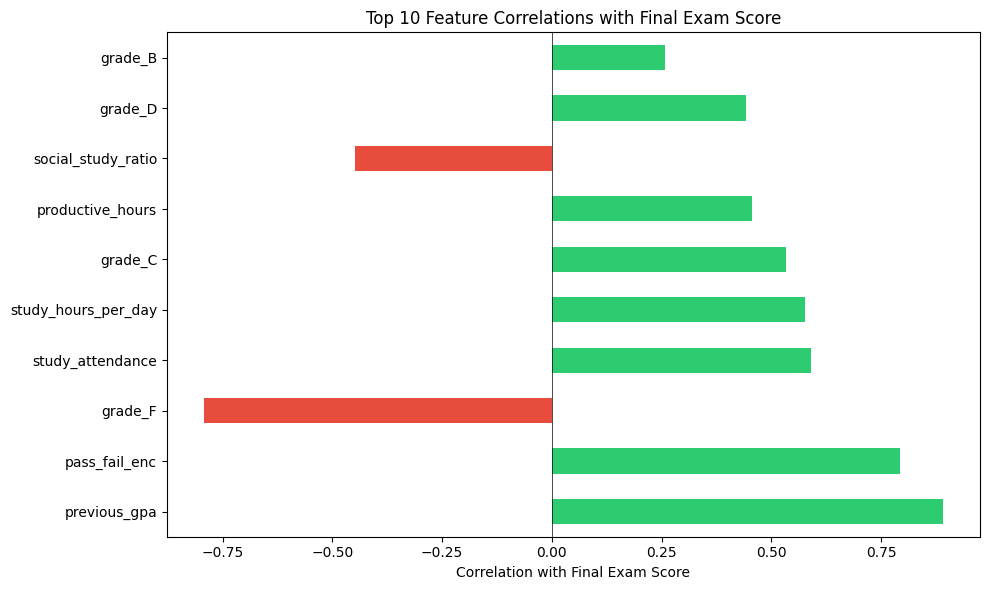

In [2]:
plt.figure(figsize=(10, 6))
target_corr.head(10).plot(kind='barh', color=['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.head(10)])
plt.xlabel('Correlation with Final Exam Score')
plt.title('Top 10 Feature Correlations with Final Exam Score')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../deliverables/figures/07_rq1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## RQ1 - Study Habits Heatmap by Grade Category (pendukung H1)

In [ ]:
habit_cols = ['study_hours_per_day', 'sleep_hours', 'social_media_hours',
              'attendance_rate', 'assignment_completion_rate']
habit_by_grade = df.groupby('grade_category')[habit_cols].mean().reindex(['A', 'B', 'C', 'D', 'F'])

plt.figure(figsize=(10, 6))
sns.heatmap(habit_by_grade, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Study Habits by Grade Category')
plt.tight_layout()
plt.savefig('../deliverables/figures/08_study_habits_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

## RQ1 - Performance Gaps by Demographics (pendukung H1)

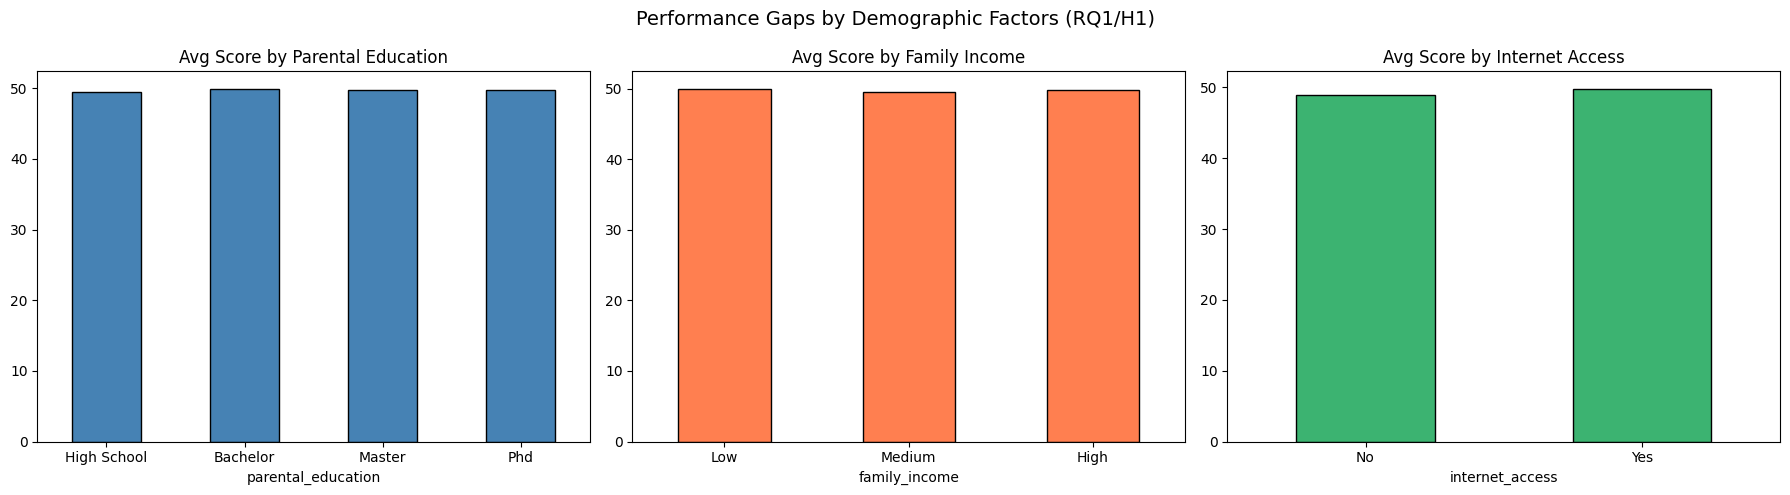

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df.groupby('parental_education')['final_exam_score'].mean().reindex(
    ['High School', 'Bachelor', 'Master', 'Phd']).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Avg Score by Parental Education')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('family_income')['final_exam_score'].mean().reindex(
    ['Low', 'Medium', 'High']).plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Avg Score by Family Income')
axes[1].tick_params(axis='x', rotation=0)

df.groupby('internet_access')['final_exam_score'].mean().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Avg Score by Internet Access')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Performance Gaps by Demographic Factors (RQ1/H1)', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/09_rq4_demographic_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

## Pass/Fail and Grade Distributions

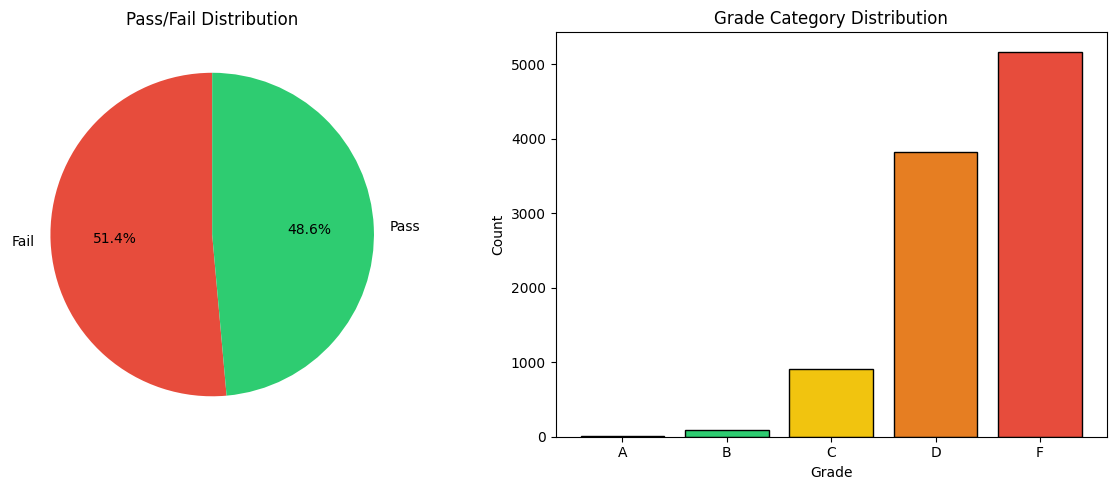

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pf_counts = df['pass_fail'].value_counts()
axes[0].pie(pf_counts, labels=pf_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0].set_title('Pass/Fail Distribution')

grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = df['grade_category'].value_counts().reindex(grade_order)
axes[1].bar(grade_counts.index, grade_counts.values, color=['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'], edgecolor='black')
axes[1].set_title('Grade Category Distribution')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../deliverables/figures/10_outcome_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Behavioral Features Pair Plot

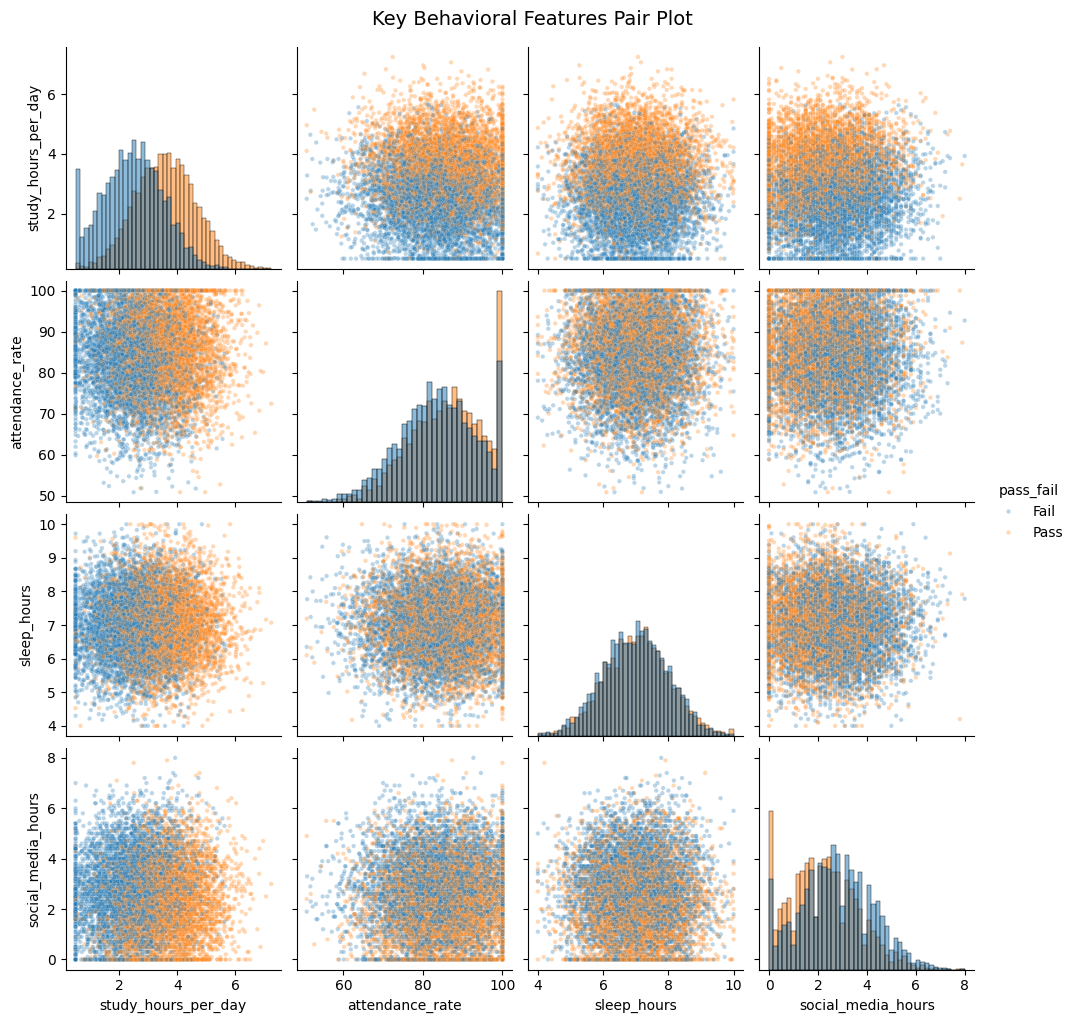

In [6]:
pair_cols = ['study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'pass_fail']
sns.pairplot(df[pair_cols], hue='pass_fail', diag_kind='hist', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Key Behavioral Features Pair Plot', y=1.02, fontsize=14)
plt.savefig('../deliverables/figures/11_pairplot_behavioral.png', dpi=150, bbox_inches='tight')
plt.show()